# Introduction
In clinical care settings, ECG interpretations are often recorded as free-text. It can be challenging to translate these into binary labels for training and evaluation due to synonyms, acronyms, grammar, typographical errors, evolving medical terminology, and implied findings.

Specifically, we:
- Apply pattern matching (patterns were hand-curated), maintaining positional information
- Derive a series of entities (e.g., 'tachycardia', 'infarction'), descriptors (e.g., 'probably', 'moderate', 'acute'), and connectives (e.g., 'associated with', 'transitions to')
- Distill elevant information from the descriptors and connectives down into their corresponding entities
- Apply a knowledge graph encoding label relationships to recursively mark labels as true, e.g., labeling *Ventricular tachycardia* when *Torsades de Pointes* was stated.
- Map the resulting entities into labels which can be flexibly manipulated.


In [1]:
import os
import pandas as pd

root = os.path.dirname(os.getcwd())
labeler_dir = os.path.join(root, 'data/mimic_iv_ecg/labeler')

labeler_results_file = os.path.join(labeler_dir, 'labeler_res.pkl')
if os.path.exists(labeler_results_file):
    os.remove(labeler_results_file)

# Load labeler

In [2]:
!pip install tqdm
!pip install networkx

In [21]:
import sys
sys.path.insert(0, os.path.join(root, 'labeler/'))

from pattern_labeler import PatternLabelerConfig, PatternLabeler
from preprocess import preprocess_texts

In [22]:
labeler_config = PatternLabelerConfig.from_json(labeler_dir)
labeler_config.entity_templates #maps text to entity

[Electrocardiogram,
 Pediatric,
 Normal electrocardiogram,
 Abnormal electrocardiogram,
 Borderline electrocardiogram,
 Normal electrocardiogram except for rate,
 Heart rate,
 Low heart rate,
 High heart rate,
 Difficulty interpreting,
 Poor data quality,
 Cannot adequately assess,
 Artifact,
 Lead misplacement,
 Lead reversal,
 Limb lead reversal,
 Arm lead reversal,
 Missing leads/data,
 Lead not used for morphology analysis,
 Lead unsuitable for analysis,
 Missing lead,
 Partial missing lead,
 Artifact in lead,
 Baseline wander in lead,
 Lead sequence error,
 Lead I unsuitable for analysis,
 Missing lead I,
 Partial missing lead I,
 Artifact in lead I,
 Baseline wander in lead I,
 Lead I not used for morphology analysis,
 Lead II unsuitable for analysis,
 Missing lead II,
 Partial missing lead II,
 Artifact in lead II,
 Baseline wander in lead II,
 Lead II not used for morphology analysis,
 Lead III unsuitable for analysis,
 Missing lead III,
 Artifact in lead III,
 Baseline wander 

In [23]:
labeler = PatternLabeler(labeler_config)
labeler

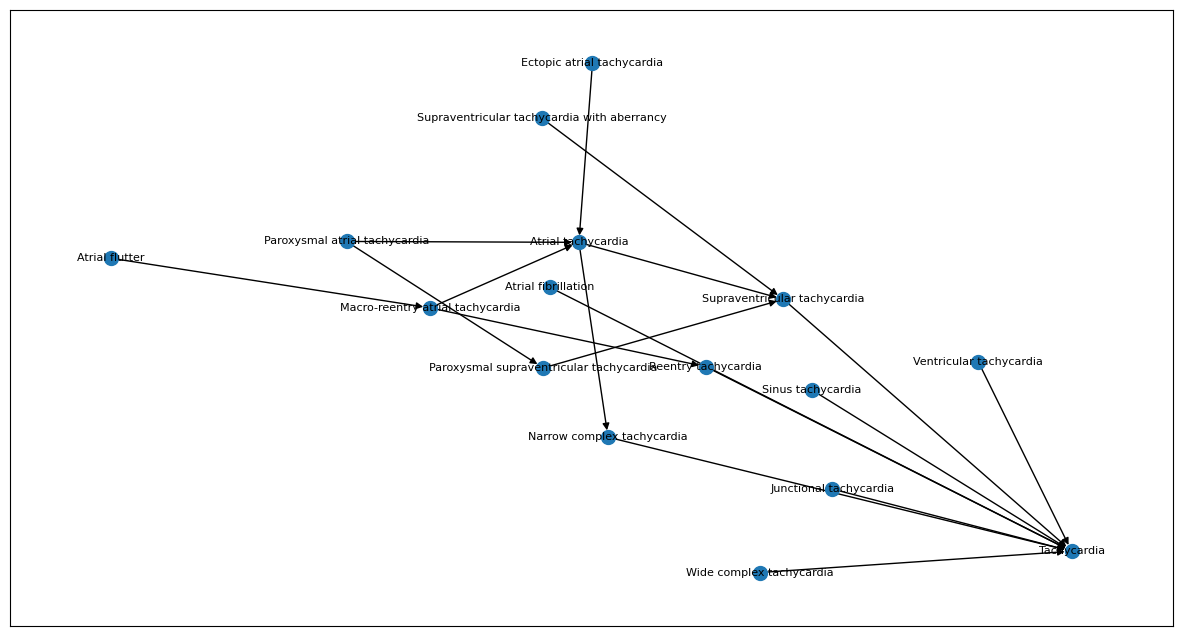

In [ ]:
labeler.plot_ancestor_subgraph( #shows all broader categories that Techycardia is a subtype of
    "Tachycardia",
    figsize=(15, 8),
    node_size=100,
    font_size=8,
)

# Preprocess

runs labeling pipeline on examples

In [ ]:
interpretations = pd.Series([
    "Sinus rhythm; Possible right atrial abnormality",
    "Sinus tach; Normal electrocardiogram except for rate",
    "Normal sinus rhtyhm; Normal ECG; missing lead v2",
    "Accelerated idioventricular rhythm; LAD; Borderline ECG",
    "Stach with PVC(s); Possible seotal infarct; Undefined",
])
texts = preprocess_texts(interpretations.copy()) #preprocesses, apparently fixes spelling mistakes
texts.rename("text", inplace=True)
texts

Pre replacements...
Replacements...
Replacements - Unbordered
Replacements - Bordered
Replacements - Regex
Post replacements...
Replacing 'pacing' conjunct patterns...


100%|██████████| 1316/1316 [00:01<00:00, 704.61it/s]


Performed replacements in 0 entries.
Replacing 'pacer entities' conjunct patterns...


100%|██████████| 40/40 [00:00<00:00, 876.94it/s]


Performed replacements in 0 entries.
Replacing 'wave abnormality' conjunct patterns...


...

100%|██████████| 170/170 [00:00<00:00, 764.21it/s]


Performed replacements in 0 entries.
Replacing 'interval length' conjunct patterns...


100%|██████████| 72/72 [00:00<00:00, 753.83it/s]

Performed replacements in 0 entries.


0      sinus rhythm; possible right atrial abnormality
1        sinus tachycardia; normal ecg except for rate
2     normal sinus rhythm; normal ecg; missing lead v2
3    accelerated idioventricular rhythm; lad; borde...
4    sinus tachycardia with premature ventricular b...
Name: text, dtype: object

# Parse

In [ ]:
labeler_res = labeler( #walk through the steps for each sentence
    texts=texts.copy(),
    restore_path=labeler_results_file,
)

Matching patterns...


100%|██████████| 14/14 [00:00<00:00, 777.27it/s]


Creating entities and attributing descriptors...
Parsing patterns into entities...


100%|██████████| 5/5 [00:00<00:00, 117.72it/s]


Applying uncertainty...
Dropped 0 entities with absence descriptors.
Recursively extract super entities...
Parsing traveling descriptors...
Parsing attached descriptors...
Recursively extract super entities...
Creating compound entities...


# Analyze results

In [9]:
import pickle

with open(labeler_results_file, "rb") as f:
    labeler_res = pickle.load(f)

## View unmatched text

In [11]:
unmatched = labeler_res.text_results['unmatched'][
    labeler_res.text_results['unmatched'] != ''
].copy()
unmatched = unmatched.str.replace("[^\w\s]", "", regex=True).str.strip()
unmatched = unmatched[unmatched != ''].copy()
unmatched

4    undefined
Name: unmatched, dtype: object

# Create labels

In [12]:
labels_flat = labeler_res.labels_flat.copy()

In [13]:
vcs = labels_flat[
    ~labels_flat['name'].str.contains(" - ", regex=False)
]['name'].value_counts()
vcs

name
Sinus rhythm                                4
Arrhythmia                                  3
High heart rate                             2
Sinus tachycardia                           2
Tachycardia                                 2
Right atrial abnormality                    1
Abnormal electrocardiogram                  1
Normal electrocardiogram except for rate    1
Difficulty interpreting                     1
Lead not used for morphology analysis       1
Lead unsuitable for analysis                1
Missing lead                                1
Missing lead V2                             1
Missing leads/data                          1
Normal electrocardiogram                    1
Poor data quality                           1
Accelerated idioventricular rhythm          1
Borderline electrocardiogram                1
Left axis deviation                         1
Ventricular rhythm                          1
Ectopic contraction                         1
Ectopic ventricular contracti

In [14]:
# Removed from UHN labels:
# Normal sinus rhythm
# 2nd degree atrioventricular block
# Ventricular pacing
# Atrial pacing

CONFIRM_LABELS = """
Poor data quality
Sinus rhythm
Sinus tachycardia
Premature ventricular contraction
Tachycardia
Right atrial abnormality
""".split("\n")
CONFIRM_LABELS = [label for label in CONFIRM_LABELS if label != ""]

In [ ]:
vcs.loc[CONFIRM_LABELS] / len(texts) #prevalence rate

name
Poor data quality                    0.2
Sinus rhythm                         0.8
Sinus tachycardia                    0.4
Premature ventricular contraction    0.2
Tachycardia                          0.4
Right atrial abnormality             0.2
Name: count, dtype: float64

In [16]:
labels_flat_final = labels_flat[labels_flat["name"].isin(CONFIRM_LABELS)]
labels = pd.get_dummies(labels_flat_final['name'])[CONFIRM_LABELS]
labels.index.name = 'idx'
labels = labels.groupby('idx').any()

# Add in rows which had no labels
no_label_rows = pd.DataFrame(index=texts.index[~texts.index.isin(labels.index)].copy(), columns=CONFIRM_LABELS)
no_label_rows.loc[:, :] = False
labels = pd.concat([labels, no_label_rows]).sort_index()
labels.index.name = 'idx'
labels

,Poor data quality,Sinus rhythm,Sinus tachycardia,Premature ventricular contraction,Tachycardia,Right atrial abnormality
idx,,,,,,
0,False,True,False,False,False,True
1,False,True,True,False,True,False
2,True,True,False,False,False,False
3,False,False,False,False,False,False
4,False,True,True,True,True,False


In [ ]:
assert len(labels) == len(texts) #checking of no lines were dropped accidentally

In [31]:
import json

with open(r"C:\Users\noors\University\thesis\ecg-fm\data\mimic_iv_ecg\labeler\entity_tem.json") as f:
    templates = json.load(f)

edges = []
for entity in templates:
    name = entity["name"]
    sup = entity.get("sup", [])
    if isinstance(sup, str):
        sup = [sup]
    for parent in sup:
        edges.append((name, parent))

print(edges)

[('Normal electrocardiogram', 'Electrocardiogram'), ('Abnormal electrocardiogram', 'Electrocardiogram'), ('Borderline electrocardiogram', 'Electrocardiogram'), ('Normal electrocardiogram except for rate', 'Electrocardiogram'), ('Low heart rate', 'Heart rate'), ('High heart rate', 'Heart rate'), ('Poor data quality', 'Difficulty interpreting'), ('Cannot adequately assess', 'Poor data quality'), ('Artifact', 'Poor data quality'), ('Lead misplacement', 'Lead unsuitable for analysis'), ('Lead reversal', 'Lead misplacement'), ('Lead reversal', 'Cannot adequately assess'), ('Limb lead reversal', 'Lead reversal'), ('Arm lead reversal', 'Limb lead reversal'), ('Missing leads/data', 'Poor data quality'), ('Missing leads/data', 'Lead unsuitable for analysis'), ('Lead not used for morphology analysis', 'Poor data quality'), ('Lead unsuitable for analysis', 'Lead not used for morphology analysis'), ('Missing lead', 'Missing leads/data'), ('Partial missing lead', 'Missing leads/data'), ('Artifact i

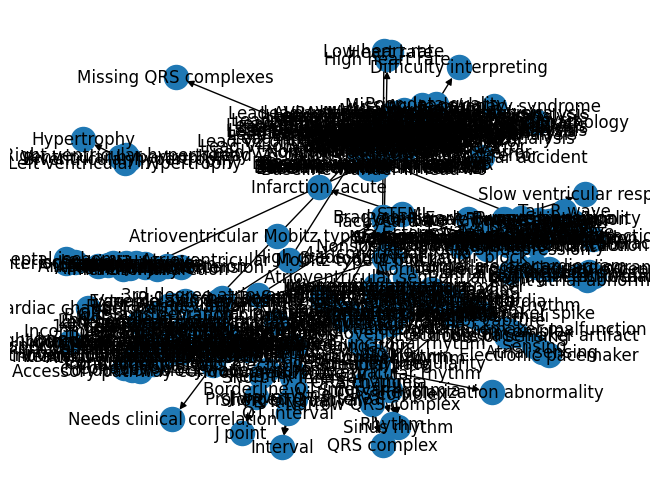

In [32]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.DiGraph()
G.add_edges_from(edges)

nx.draw(G, with_labels=True, arrows=True)
plt.show()

# Labeler definition example

If you're looking to define your own labeler, it can be easier to start from Python code, rather than writing the JSON. It can then be converted to JSON for easier distribution and versioning.

In [18]:
from typing import Dict, List, Optional, Union

from pattern_labeler import (
    AttachedDescriptorTem,
    CompoundTem,
    Connective,
    DescriptorTem,
    Entity,
    EntityPattern,
    EntityTem,
    SplitDescriptorTem,
    TravelingDescriptorsTem,
    DescriptorPattern
)

ENTITY_TEMPLATES: List[EntityTem] = [
    EntityTem("Sinus rhythm"),
    EntityTem("Arrhythmia"),
    EntityTem("Tachycardia", sup="Arrhythmia"),
    EntityTem("Sinus tachycardia", sup=["Sinus rhythm", "Tachycardia"]),
    EntityTem("Ectopic beat"),
    EntityTem("Ectopic ventricular contraction", sup="Ectopic beat"),
    EntityTem("Bifascicular block"),
    EntityTem("Right bundle branch block"),
    EntityTem("Fascicular block"),
]

ENTITY_PATTERNS: List[EntityPattern] = [
    EntityPattern("tachycardia", "Tachycardia"),
    EntityPattern("ectopic beat", "Ectopic beat"),
]

DESCRIPTOR_TEMPLATES: List[DescriptorTem] = [
    DescriptorTem("Severe", category="severity"),
    DescriptorTem("Sinus", category="location"),
    DescriptorTem("Atrial", category="location"),
    DescriptorTem("Ventricular", category="location"),
    DescriptorTem("Multiple", category="quantity"),
    DescriptorTem("Possible", category="uncertainty"),
    DescriptorTem("Probable", category="uncertainty"),
]

DESCRIPTOR_PATTERNS: List[DescriptorPattern] = [
    DescriptorPattern("severe", "Severe"),
    DescriptorPattern("atrial", "Atrial"),
    DescriptorPattern("possible", "Possible"),
    DescriptorPattern("probably", "Probable"),
    DescriptorPattern("multiple", "Multiple"),
]

# === Connectives ===
CONNECTIVES: List[Connective] = [
    Connective("and"),
    Connective("suggests", descriptors=[None, "Probable"], tags="causal"),
]

SPLIT_DESCRIPTOR_TEMPLATES: List[SplitDescriptorTem] = [
    SplitDescriptorTem(
        "Atrioventricular",
        split=["Atrial", "Ventricular"],
        patterns="atrioventricular",
    ),
]

COMPOUND_TEMPLATES: List[CompoundTem] = [
    CompoundTem(
        "Bifascicular block",
        ["Right bundle branch block", "Fascicular block"],
    ),
]

ATTACHED_DESCRIPTOR_TEMPLATES: List[AttachedDescriptorTem] = [
    AttachedDescriptorTem("Atrial tachycardia", "Tachycardia", "Atrial"),
]

TRAVELING_DESCRIPTOR_TEMPLATES: List[TravelingDescriptorsTem] = [
    TravelingDescriptorsTem("Ectopic Beat", ["Multiple"]),
]

UNCERTAINTY_MAP: Dict[str, float] = {
    "Possible": 0.5,
    "Probable": 0.7,
}

In [19]:
labeler_config = PatternLabelerConfig(
    ENTITY_TEMPLATES,
    ENTITY_PATTERNS,
    descriptor_templates=DESCRIPTOR_TEMPLATES,
    descriptor_patterns=DESCRIPTOR_PATTERNS,
    split_descriptor_templates=SPLIT_DESCRIPTOR_TEMPLATES,
    connectives=CONNECTIVES,
    compound_templates=COMPOUND_TEMPLATES,
    attached_descriptor_templates=ATTACHED_DESCRIPTOR_TEMPLATES,
    traveling_descriptor_templates=TRAVELING_DESCRIPTOR_TEMPLATES,
    uncertainty_map=UNCERTAINTY_MAP,
)
labeler = PatternLabeler(labeler_config)
labeler

In [20]:
custom_labeler_dir = os.path.join(root, 'data/custom_labeler')
labeler_config.to_json(custom_labeler_dir)